In [1]:
import numpy as np 
import requests
import pandas as pd
from io import StringIO
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess

In [49]:
url = "http://stat.cmu.edu/~larry/=stat401/sports.txt"

resp = requests.get(url, verify=False)
resp.raise_for_status()

df = pd.read_csv(StringIO(resp.text), sep=r"\s+", engine="python")
df.columns = df.columns.str.replace('"', '', regex=False).str.strip()
df.to_csv("sports.csv", index=False)

df.drop(columns=["Sport", "Label"], inplace=True)

df["Sex"] = df["Sex"].astype("category")

print(df.head())
print(df.shape)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'stat.cmu.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  Sex     Ht    Wt    LBM   RCC  WCC    Hc    Hg  Ferr    BMI    SSF   Bfat
0   1  195.9  78.9  63.32  3.96  7.5  37.5  12.3    60  20.56  109.1  19.75
1   1  189.7  74.4  58.55  4.41  8.3  38.2  12.7    68  20.67  102.8  21.30
2   1  177.8  69.1  55.36  4.14  5.0  36.4  11.6    21  21.86  104.6  19.88
3   1  185.0  74.9  57.18  4.11  5.3  37.3  12.6    69  21.88  126.4  23.66
4   1  184.6  64.6  53.20  4.45  6.8  41.5  14.0    29  18.96   80.3  17.64
(202, 12)


# Q1 a)

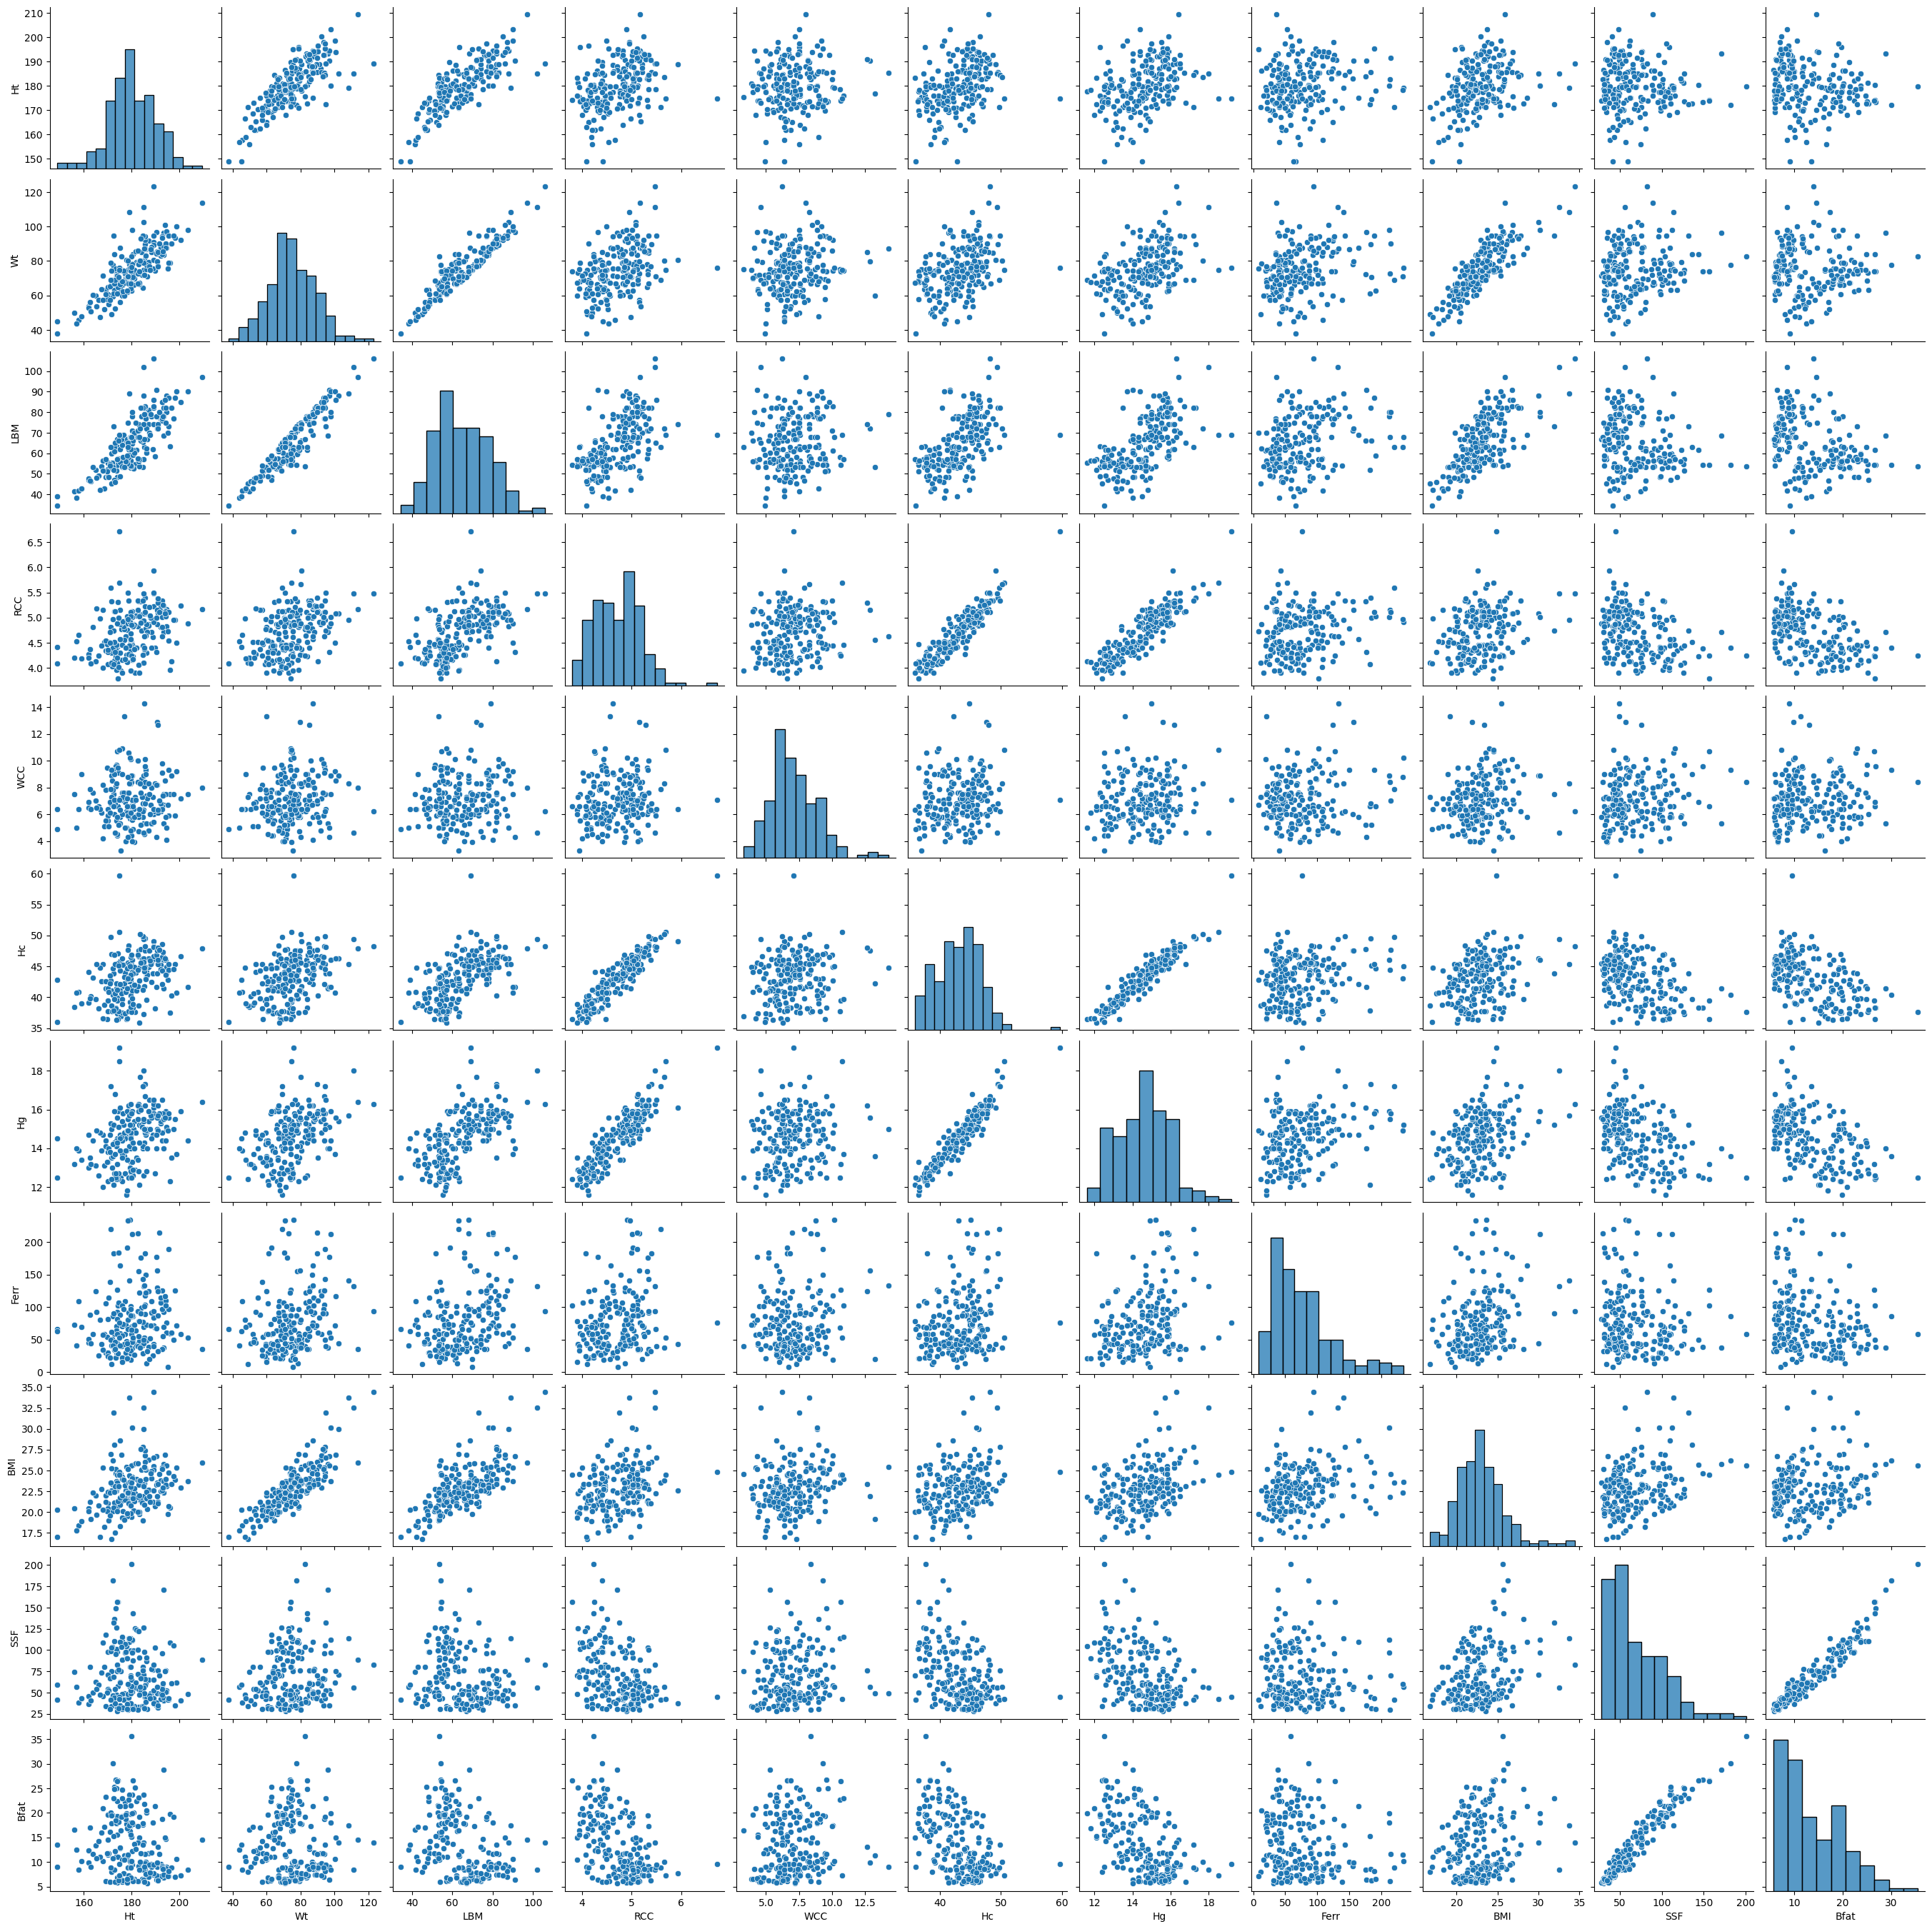

In [3]:
sns.pairplot(df)
plt.show()

Already looks like there is some collinearity/multicollinearity between the predictors

In [4]:
model = smf.ols("LBM ~ C(Sex) + Ht + Wt + RCC + WCC + Hc + Hg + Ferr + BMI + Bfat", data=df).fit()

print(model.summary())

ci = model.conf_int(alpha=0.05)
print(ci)

residuals = model.resid

                            OLS Regression Results                            
Dep. Variable:                    LBM   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                     7954.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          2.05e-244
Time:                        16:10:48   Log-Likelihood:                -195.88
No. Observations:                 202   AIC:                             413.8
Df Residuals:                     191   BIC:                             450.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.9981      5.899      0.508      

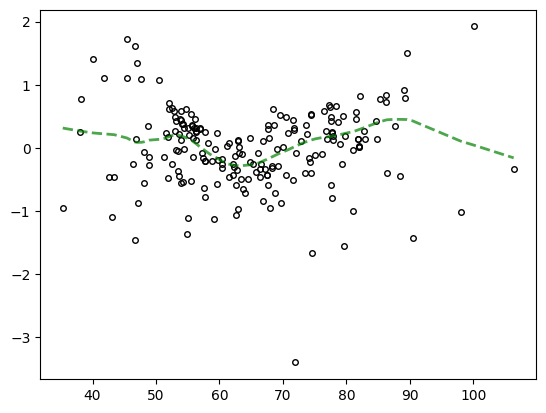

In [5]:
fitted_vals = model.fittedvalues
smooth = lowess(residuals, fitted_vals, frac=0.3) 

plt.plot(fitted_vals, residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)

Either heteroscedasticity or non-linear relationship

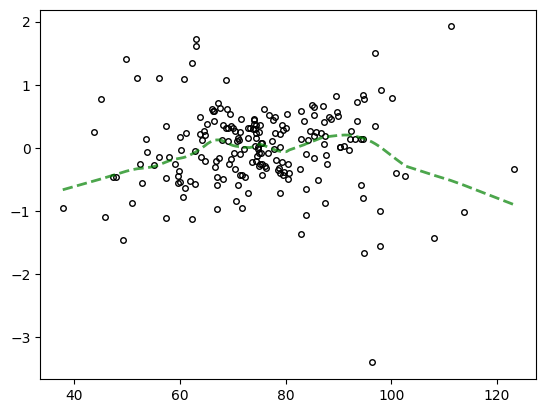

In [6]:
fitted_vals = model.fittedvalues
smooth = lowess(residuals, df["Wt"], frac=0.3) 

plt.plot(df["Wt"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)

Seems like heteroscedasticity, as the plots between Wt and LBM seem to be fairly linear in the EDA

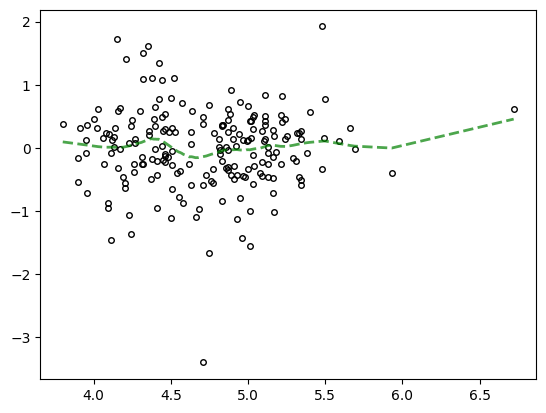

In [7]:
fitted_vals = model.fittedvalues
smooth = lowess(residuals, df["RCC"], frac=0.3) 

plt.plot(df["RCC"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)

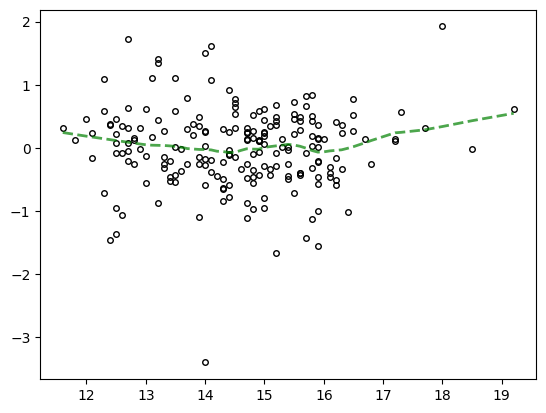

In [8]:
fitted_vals = model.fittedvalues
smooth = lowess(residuals, df["Hg"], frac=0.3) 

plt.plot(df["Hg"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)

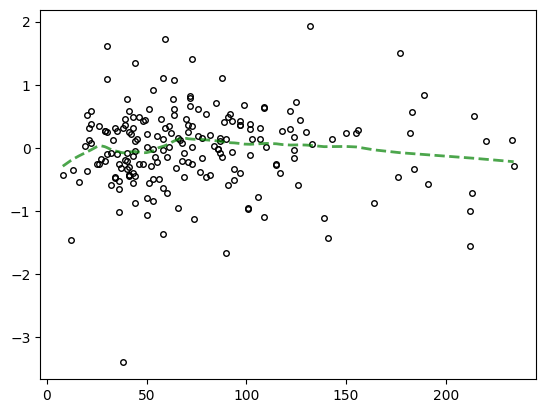

In [9]:
fitted_vals = model.fittedvalues
smooth = lowess(residuals, df["Ferr"], frac=0.3) 

plt.plot(df["Ferr"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)

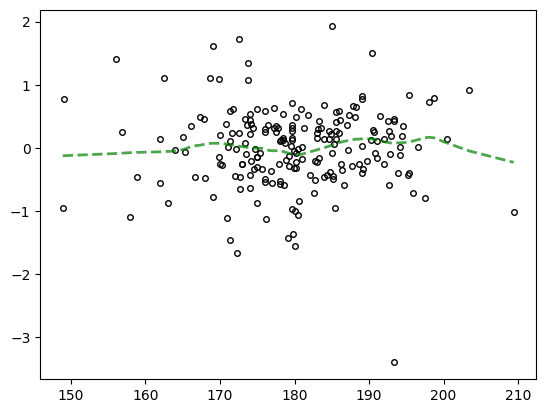

In [10]:
fitted_vals = model.fittedvalues
smooth = lowess(residuals, df["Ht"], frac=0.3) 

plt.plot(df["Ht"], residuals, 'o', markersize=4, fillstyle='none', color='black')
plt.plot(smooth[:, 0], smooth[:, 1], '--', alpha=0.7, color="green", linewidth=2)

Most variables seem to be multicollinear; no heteroscedasticity issues/linearity issues with the predictors except Wt. Can reliably distinguish the $\beta_\text{Wt}$ from 0 (difference between $\beta_\text{Wt}$ and $0$ is statistically significant), but can't say the same for the rest. Confidence intervals for all predictor coefficients are all tight and around $0$, which implies that $\beta$'s might actually be $0$. This smells like multicollinearity.

In [11]:
e = model.eigenvals
print(e)

[9.56899742e+06 3.82255215e+05 2.05090974e+04 8.52355943e+03
 2.36750255e+03 5.85929502e+02 3.19760326e+02 2.77332484e+01
 8.83172265e+00 5.76946320e+00 1.23675694e-02]


In [12]:
cr = model.conf_int(alpha=(0.1/10))
print(cr)

                     0          1
Intercept   -12.350175  18.346311
C(Sex)[T.1]  -0.291750   0.886551
Ht           -0.043341   0.128332
Wt            0.739636   0.951624
RCC          -0.665028   0.735230
WCC          -0.085886   0.054229
Hc           -0.117795   0.145496
Hg           -0.392723   0.235020
Ferr         -0.002594   0.003288
BMI          -0.279078   0.419170
Bfat         -0.814953  -0.738315


In [13]:
model_small = smf.ols("LBM ~ C(Sex) + Ht + Wt + RCC", data=df).fit()

print(model_small.summary())
print(model_small.conf_int(alpha=0.05))

                            OLS Regression Results                            
Dep. Variable:                    LBM   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     1111.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):          6.61e-134
Time:                        16:10:55   Log-Likelihood:                -486.22
No. Observations:                 202   AIC:                             982.4
Df Residuals:                     197   BIC:                             999.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -1.7433      5.984     -0.291      

In [26]:
bs = model_small.bse

print(bs)

Intercept      5.983649
C(Sex)[T.1]    0.593070
Ht             0.032831
Wt             0.022682
RCC            0.575695
dtype: float64


In [42]:
from scipy.stats import chi2
from scipy.stats import f

a = bs["Ht"] * np.sqrt(chi2.pdf(0.95, 2))
b = bs["Wt"] * np.sqrt(chi2.pdf(0.95, 2))

print("axis 1 length: ", a)
print("axis 2 length: ", b)

axis 1 length:  0.018307542951068248
axis 2 length:  0.012647961740456352


In [39]:
cov_full = model_small.cov_params()

# Extract 2x2 covariance matrix for b1 and b2
cov_b1_b2 = cov_full.loc[["Ht", "Wt"], ["Ht", "Wt"]]

b_Ht = model_small.params["Ht"]
b_Wt = model_small.params["Wt"]

print(cov_b1_b2)
print(b_Ht, b_Wt)

          Ht        Wt
Ht  0.001078 -0.000512
Wt -0.000512  0.000514
0.10485511795593208 0.6408123472191565


In [57]:
A = np.linalg.inv(cov_b1_b2)
centre = np.array([b_Ht, b_Wt])
vals, vecs = np.linalg.eigh(A)

# Axes lengths (for the ellipse formula (y-x)^T A (y-x)=1)
# The ellipse equation in standard form is: (X/a)^2 + (Y/b)^2 = 1
# Axes lengths = 1/sqrt(eigenvalues)
width, height = (2 * np.sqrt(chi2.ppf(0.95, 2))) / np.sqrt(vals)   # factor of 2 for matplotlib width/height
# width, height = (2 * np.sqrt(f.ppf(0.95, 2, 202 - 4 - 1))) / np.sqrt(vals)   # factor of 2 for matplotlib width/height


# Angle in degrees
angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

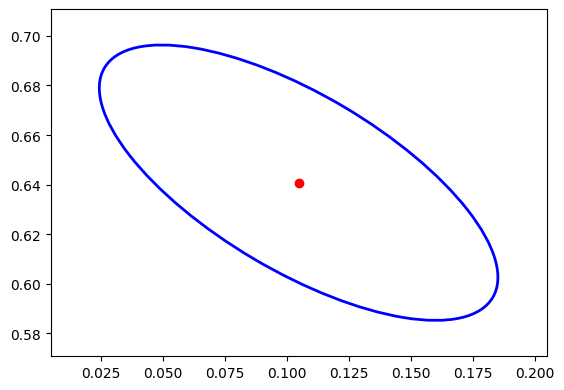

In [62]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()

ellipse = Ellipse(
    xy=centre, 
    width=width, 
    height=height, 
    angle=angle, 
    edgecolor='blue', 
    facecolor='none', 
    linewidth=2
)

ax.add_patch(ellipse)
ax.scatter(*centre, color='red', zorder=3)  # center

ax.set_aspect('equal')
plt.xlim(centre[0]-0.1, centre[0]+0.1)
plt.ylim(centre[1]-0.07, centre[1]+0.07)
plt.show()